#EMBEDDING + ATTENTION NN

##1. Import libraries

This section imports all required libraries for data processing, model building, and evaluation.

In [1]:
# Import libraries

import os, random, numpy as np, pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, roc_curve

from tensorflow.keras.layers import (
    Input, Embedding, Flatten, Dense, Concatenate,
    Dropout, BatchNormalization, Multiply
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

##2. Fix the random seed across all libraries.

Ensuring reproducibility

In [2]:
# Random seed

seed = 42
os.environ["PYTHONHASHSEED"] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
tf.keras.utils.set_random_seed(seed)

print("Seed:", seed)

Seed fixed: 42


##3. Load Dataset

The dataset is loaded and column names are cleaned.

In [3]:
# Load data
df = pd.read_csv("/content/digital_marketing_campaign_dataset.csv")
df.columns = df.columns.str.strip()

target = "Conversion"

# Drop leakage
df = df.drop(columns=["CustomerID", "ConversionRate"], errors="ignore")

##4. Feature Engineering

In [4]:
# Feature Engineering
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = df.select_dtypes(exclude=["object"]).columns.tolist()

if target in numerical_cols:
    numerical_cols.remove(target)

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: ['Gender', 'CampaignChannel', 'CampaignType', 'AdvertisingPlatform', 'AdvertisingTool']
Numerical: ['Age', 'Income', 'AdSpend', 'ClickThroughRate', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints']


##5. Train / Validation / Test Split

Dataset is split into:
- 70% Training
- 15% Validation
- 15% Testing

In [5]:
# Train/Val/Test split (70/15/15)

X = df.drop(columns=[target])
y = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("\n Distribution of y_test:")
print(y_test.value_counts())

print("\n Distribution of y_test (%):")
print(y_test.value_counts(normalize=True))

print("\n")

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)



 Distribution of y_test:
Conversion
1    1052
0     148
Name: count, dtype: int64

 Distribution of y_test (%):
Conversion
1    0.876667
0    0.123333
Name: proportion, dtype: float64


Train: (5600, 17)
Val: (1200, 17)
Test: (1200, 17)


##6. Encode Categorical Variables

Objective: apply LabelEncoder to transform categorical values into numeric format

In [6]:
# Encode category
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()

    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_val[col] = le.transform(X_val[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

    label_encoders[col] = le


##7. Scale Numerical Features

StandardScaler: normalize numerical features

In [7]:
# Scale numerical(no leakage)
scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val[numerical_cols] = scaler.transform(X_val[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])



##8. Model Architecture
Key components
- Embedding layers for categorical variables
- Concatenation with numerical inputs
- Attention mechanism for feature weighting
- Fully connected layers (MLP)
- Dropout and Batch Normalization for regularization
- Sigmoid output layer for binary classification


In [8]:
# Build model(Embeding + Attention)

tf.keras.backend.clear_session()

inputs = []
embeddings = []

# Embedding
for col in categorical_cols:
    inp = Input(shape=(1,), name=f"{col}_input")  # fix duplicate name

    vocab_size = X_train[col].nunique() + 1
    embed_dim = min(50, vocab_size // 2)

    emb = Embedding(vocab_size, embed_dim)(inp)
    emb = Flatten()(emb)

    inputs.append(inp)
    embeddings.append(emb)

# Numerical
num_input = Input(shape=(len(numerical_cols),), name="numerical_input")
inputs.append(num_input)

# Concat
x = Concatenate()(embeddings + [num_input])

# Attention
attention_scores = Dense(64, activation="tanh")(x)
attention_weights = Dense(x.shape[-1], activation="softmax")(attention_scores)
x = Multiply()([x, attention_weights])

# MLP
x = BatchNormalization()(x)

x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)

x = Dense(32, activation="relu")(x)

# Output
output = Dense(1, activation="sigmoid")(x)

# Model
model = Model(inputs=inputs, outputs=output)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Gender_input        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CampaignChannel_in… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CampaignType_input  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ AdvertisingPlatfor… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ AdvertisingTool_in… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 1)      │          3 │ Gender_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 3)      │         18 │ CampaignChannel_… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 1, 2)      │         10 │ CampaignType_inp… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 1)      │          2 │ AdvertisingPlatf… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 1, 1)      │          2 │ AdvertisingTool_… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1)         │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3)         │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 2)         │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 1)         │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 1)         │          0 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numerical_input     │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 20)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ flatten_2[0][0],  │
│                     │                   │            │ flatten_3[0][0],  │
│                     │                   │            │ flatten_4[0][0],  │
│                     │                   │            │ numerical_input[

 Total params: 15,816 (61.78 KB)

 Trainable params: 15,776 (61.62 KB)

 Non-trainable params: 40 (160.00 B)

##9. Key components
Objectives:
- Mapping categorical features to corresponding input layers
- Grouping numerical features into a single input tensor
- Creating structured input dictionaries for the model
- Preparing separate inputs for training, validation, and testing datasets


In [9]:
# Prepare input

def prepare_inputs(X):
    data = {f"{col}_input": X[col].values for col in categorical_cols}
    data["numerical_input"] = X[numerical_cols].values
    return data

train_inputs = prepare_inputs(X_train)
val_inputs = prepare_inputs(X_val)
test_inputs = prepare_inputs(X_test)

##10. Model Training

- Training the model on prepared input data
- Validation on a separate dataset during training
- Early stopping based on validation loss
- Restoring best model weights to prevent overfitting
- Configuring epochs and batch size for optimization
- Tracking training history for performance analysis


In [10]:
# Training Model
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_inputs,
    y_train,
    validation_data=(val_inputs, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.8745 - loss: 0.3748 - val_accuracy: 0.8767 - val_loss: 0.4396
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8766 - loss: 0.3253 - val_accuracy: 0.8767 - val_loss: 0.3773
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8827 - loss: 0.3127 - val_accuracy: 0.8783 - val_loss: 0.3367
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8907 - loss: 0.2976 - val_accuracy: 0.8742 - val_loss: 0.3263
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8957 - loss: 0.2894 - val_accuracy: 0.8808 - val_loss: 0.3226
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8989 - loss: 0.2823 - val_accuracy: 0.8742 - val_loss: 0.3266
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8980 - loss: 0.2794 - val_accuracy: 0.8825 - val_loss: 0.3245
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9027 - loss: 0.2755 - val_accuracy:

##11. Model Evaluation

- AUC (Area Under Curve)
- F1-score

In [11]:
# Evaluation

y_pred_prob = model.predict(test_inputs)
y_pred = (y_pred_prob > 0.5).astype(int)

print("AUC:", roc_auc_score(y_test, y_pred_prob))
print("F1:", f1_score(y_test, y_pred))


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
AUC: 0.7636066437159593
F1: 0.9343807763401109


##12. Confusion Matrix

Visualizes classification performance

- True Positive
- False Positive
- True Negative
- False Negative

Confusion Matrix:
[[  47  101]
 [  41 1011]]

TN (True Negative): 47
FP (False Positive): 101
FN (False Negative): 41
TP (True Positive): 1011


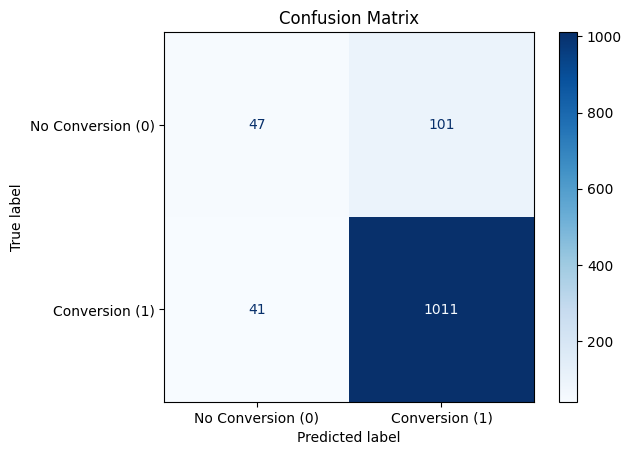

In [15]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print(f"\nTN (True Negative): {tn}")
print(f"FP (False Positive): {fp}")
print(f"FN (False Negative): {fn}")
print(f"TP (True Positive): {tp}")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Conversion (0)", "Conversion (1)"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()



###Accuracy, Precision, Recal, F1

In [17]:
# Accuracy, Precision, Recal, F1
total = cm.sum()

print("\nRates:")
print(f"Accuracy: {(tp + tn) / total:.4f}")
print(f"Precision: {tp / (tp + fp):.4f}")
print(f"Recall: {tp / (tp + fn):.4f}")




Rates:
Accuracy: 0.8817
Precision: 0.9092
Recall: 0.9610


##12. ROC Curve
Shows trade-off between:
- False Positive Rate
- True Positive Rate

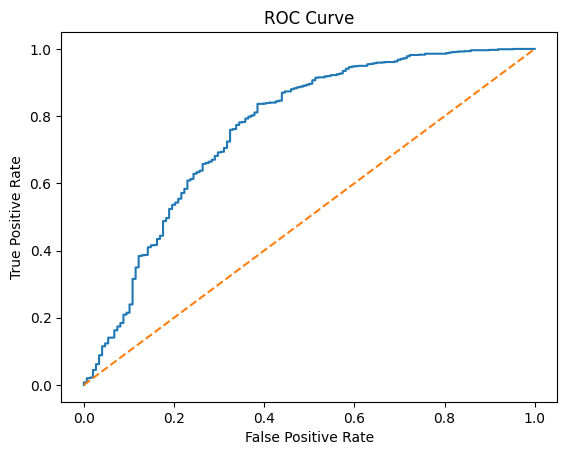

In [18]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


##14. Training Curve
We plot:
- Training loss
- Validation loss to monior model performance and overfitting.

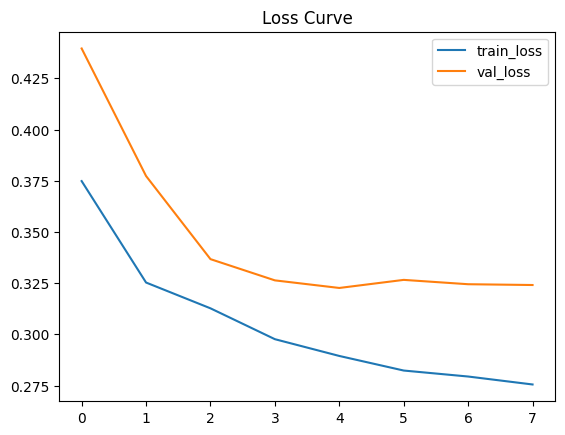

In [19]:
# Training Curve

plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss Curve")
plt.show()